# Experimento 5 — Ajuste del detector de opinión y análisis del techo

Clasificación de sentimiento de reseñas — Parte 1 (ML clásico). Aprendizaje de Máquina 2026-20, Universidad de los Andes.

Este notebook continúa `experimento4.ipynb` (el mejor modelo según la CV). La sección 1 repite de forma resumida la
configuración común (misma semilla, mismo split y mismos folds). Los experimentos anteriores **no se vuelven a
ejecutar**: sus métricas se registran como valores fijos tomados de sus notebooks.

**Contenido**
1. Configuración común (resumen)
2. Experimento 5 — Ajuste del detector de opinión y análisis del techo

## 1. Configuración común (resumen)

### 1.1 Librerías, semilla y datos

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.base import clone

SEED = 42
np.random.seed(SEED)

CLASES = ["negativo", "neutral", "positivo"]

pd.set_option("display.max_colwidth", 200)
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.axisbelow": True,
})

train = pd.read_csv("train.csv").copy()
eval_df = pd.read_csv("eval.csv").copy()
sample_submission = pd.read_csv("sample_submission.csv")
conteo = train["label"].value_counts().reindex(CLASES)

print("train:", train.shape, "| eval:", eval_df.shape)

train: (12000, 3) | eval: (3000, 2)


### 1.2 Normalización base

La misma función de `experimento1.ipynb` (sección 2): reparar mojibake, minúsculas, quitar tildes conservando la ñ,
reducir letras repetidas 3+ veces a 2 y colapsar espacios. Conserva stopwords y puntuación.

In [2]:
TILDES = str.maketrans("áéíóúàèìòùäëïöüâêîôû", "aeiouaeiouaeiouaeiou")
PATRON_MOJIBAKE = re.compile(r"Ã[\x80-\xbf]")
PATRON_REPETIDAS = re.compile(r"([a-zñ])\1{2,}")


def reparar_mojibake(texto):
    return PATRON_MOJIBAKE.sub(lambda m: m.group().encode("latin-1").decode("utf-8"), texto)


def normalizar_texto(texto):
    texto = reparar_mojibake(texto)
    texto = texto.lower()
    texto = texto.translate(TILDES)
    texto = PATRON_REPETIDAS.sub(r"\1\1", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


train["text_norm"] = train["text"].map(normalizar_texto)
eval_df["text_norm"] = eval_df["text"].map(normalizar_texto)

### 1.3 Validación y métricas

Split 80/20 estratificado (el 20 % es el test hold-out, que solo se reporta) y CV estratificada de 5 folds sobre el
80 %. Se decide con accuracy (métrica de Kaggle) y se reporta F1 macro como control.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    train["text_norm"], train["label"], test_size=0.20, stratify=train["label"], random_state=SEED
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = {"accuracy": "accuracy", "f1_macro": "f1_macro"}

print(f"Entrenamiento + validación: {len(X_train):,}  |  Test: {len(X_test):,}")

Entrenamiento + validación: 9,600  |  Test: 2,400


### 1.4 Funciones auxiliares

Las mismas de `experimento1.ipynb` (sección 3.2 y 4.3).

In [4]:
# Métricas del experimento 1 tomadas de experimento1.ipynb (no se vuelve a ejecutar aquí)
REFERENCIA_E1 = {
    "experimento": 1,
    "descripcion": "Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",
    "mejores_params": {"clf__C": 10},
    "acc_train": 0.9973,
    "acc_cv": 0.7364,
    "std_cv": 0.0128,
    "f1_cv": 0.7478,
    "acc_test": 0.7238,
    "f1_test": 0.7366,
    "envio": "submission_01.csv",
    "kaggle_publico": None,
    "acc_neg_vs_pos_test": 0.607,
}

resultados = [{k: v for k, v in REFERENCIA_E1.items() if k != "acc_neg_vs_pos_test"}]


def contiene(serie, patron):
    """Serie booleana: True si el texto contiene el patrón."""
    return serie.map(lambda t: re.search(patron, t) is not None)


def tabla_cv(busqueda):
    """Resultados de un GridSearchCV ordenados por accuracy de validación."""
    cv = pd.DataFrame(busqueda.cv_results_)
    tabla = pd.DataFrame({
        "params": cv["params"],
        "acc_train": cv["mean_train_accuracy"],
        "acc_cv": cv["mean_test_accuracy"],
        "std_cv": cv["std_test_accuracy"],
        "f1_cv": cv["mean_test_f1_macro"],
        "seg_ajuste": cv["mean_fit_time"],
    })
    return tabla.sort_values("acc_cv", ascending=False).round(4)


def evaluar_en_test(modelo, titulo):
    """Accuracy, F1 macro, reporte por clase y matriz de confusión sobre el test (hold-out)."""
    pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average="macro")
    print(f"Test -> accuracy: {acc:.4f} | F1 macro: {f1:.4f}\n")
    print(classification_report(y_test, pred, labels=CLASES, digits=3))

    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=CLASES, cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(f"Matriz de confusión en test\n{titulo}")
    ax.set_xlabel("Clase predicha")
    ax.set_ylabel("Clase real")
    ax.grid(False)
    plt.show()
    return {"acc_test": acc, "f1_test": f1, "pred": pred}


def registrar_resultado(experimento, descripcion, busqueda, metricas_test, envio=None, kaggle_publico=None):
    """Agrega a la tabla de resultados el mejor modelo de un GridSearchCV."""
    i = busqueda.best_index_
    cv = busqueda.cv_results_
    resultados.append({
        "experimento": experimento,
        "descripcion": descripcion,
        "mejores_params": busqueda.best_params_,
        "acc_train": round(cv["mean_train_accuracy"][i], 4),
        "acc_cv": round(cv["mean_test_accuracy"][i], 4),
        "std_cv": round(cv["std_test_accuracy"][i], 4),
        "f1_cv": round(cv["mean_test_f1_macro"][i], 4),
        "acc_test": round(metricas_test["acc_test"], 4),
        "f1_test": round(metricas_test["f1_test"], 4),
        "envio": envio,
        "kaggle_publico": kaggle_publico,
    })
    return pd.DataFrame(resultados)


def generar_envio(busqueda, numero):
    """Reentrena la mejor configuración con las 12.000 reseñas, predice eval y guarda envío y modelo."""
    modelo = clone(busqueda.best_estimator_)
    modelo.fit(train["text_norm"], train["label"])

    envio = pd.DataFrame({"id": eval_df["id"], "answer": modelo.predict(eval_df["text_norm"])})

    assert list(envio.columns) == ["id", "answer"]
    assert len(envio) == len(sample_submission) == 3000
    assert set(envio["id"]) == set(sample_submission["id"])
    assert set(envio["answer"]) <= set(CLASES)

    Path("envios").mkdir(exist_ok=True)
    Path("modelos").mkdir(exist_ok=True)
    ruta_envio = f"envios/submission_{numero:02d}.csv"
    ruta_modelo = f"modelos/modelo_{numero:02d}.joblib"
    envio.to_csv(ruta_envio, index=False)
    joblib.dump(modelo, ruta_modelo)

    print(f"Envío guardado en {ruta_envio} y modelo en {ruta_modelo}")
    print("Distribución de predicciones en eval (%):")
    print((envio["answer"].value_counts(normalize=True).reindex(CLASES) * 100).round(1).to_string())
    return envio


def top_coeficientes(modelo, n=15):
    """N-gramas con mayor coeficiente por clase."""
    nombres = modelo.named_steps["tfidf"].get_feature_names_out()
    clf = modelo.named_steps["clf"]
    tabla = {}
    for k, clase in enumerate(clf.classes_):
        orden = clf.coef_[k].argsort()[::-1][:n]
        tabla[clase] = [f"{nombres[i]} ({clf.coef_[k][i]:.2f})" for i in orden]
    return pd.DataFrame(tabla)[CLASES]

In [5]:
# Métricas de los experimentos 2, 3 y 4 tomadas de sus notebooks (no se vuelven a ejecutar aquí)
for fila in [
    {"experimento": 2, "descripcion": "TF-IDF (1,2) de texto completo + última oración + tras el último conector + LR",
     "mejores_params": {"clf__C": 10}, "acc_train": 0.9999, "acc_cv": 0.8865, "std_cv": 0.0099, "f1_cv": 0.8908,
     "acc_test": 0.8992, "f1_test": 0.9031, "envio": "submission_02.csv", "kaggle_publico": 0.88},
    {"experimento": 3, "descripcion": "TF-IDF (1,2) de texto completo + oraciones con conector conclusivo + LR (sin posición)",
     "mejores_params": {"clf__C": 10}, "acc_train": 0.9980, "acc_cv": 0.7978, "std_cv": 0.0146, "f1_cv": 0.8064,
     "acc_test": 0.7963, "f1_test": 0.8054, "envio": "submission_03.csv", "kaggle_publico": None},
    {"experimento": 4, "descripcion": "Texto completo + última oración con opinión (detector) + tras conector sin evasivas, LinearSVC",
     "mejores_params": {"clf": "LinearSVC", "clf__C": 0.2}, "acc_train": 0.9770, "acc_cv": 0.9009, "std_cv": 0.0057,
     "f1_cv": 0.9055, "acc_test": 0.8975, "f1_test": 0.9021, "envio": "submission_04.csv", "kaggle_publico": None},
]:
    resultados.append(fila)

# Accuracy por fold del experimento 4 (mismos folds; experimento4.ipynb, sección 2.4)
ACC_FOLDS_E4 = np.array([0.9021, 0.9010, 0.9052, 0.9062, 0.8901])

# Prueba de robustez en test de los experimentos anteriores (sus notebooks)
ROBUSTEZ_TEST_REF = pd.DataFrame([
    {"modelo": "Exp. 2", "escenario": "Original", "accuracy": 0.8992},
    {"modelo": "Exp. 2", "escenario": "Oraciones desordenadas", "accuracy": 0.6858},
    {"modelo": "Exp. 2", "escenario": "Última oración al inicio", "accuracy": 0.5742},
    {"modelo": "Exp. 4", "escenario": "Original", "accuracy": 0.8975},
    {"modelo": "Exp. 4", "escenario": "Oraciones desordenadas", "accuracy": 0.7358},
    {"modelo": "Exp. 4", "escenario": "Última oración al inicio", "accuracy": 0.5946},
])
pd.DataFrame(resultados)

,experimento,descripcion,mejores_params,acc_train,acc_cv,std_cv,f1_cv,acc_test,f1_test,envio,kaggle_publico
0,1,"Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",{'clf__C': 10},0.9973,0.7364,0.0128,0.7478,0.7238,0.7366,submission_01.csv,NaN
1,2,"TF-IDF (1,2) de texto completo + última oración + tras el último conector + LR",{'clf__C': 10},0.9999,0.8865,0.0099,0.8908,0.8992,0.9031,submission_02.csv,0.88
2,3,"TF-IDF (1,2) de texto completo + oraciones con conector conclusivo + LR (sin posición)",{'clf__C': 10},0.9980,0.7978,0.0146,0.8064,0.7963,0.8054,submission_03.csv,NaN
3,4,"Texto completo + última oración con opinión (detector) + tras conector sin evasivas, LinearSVC","{'clf': 'LinearSVC', 'clf__C': 0.2}",0.9770,0.9009,0.0057,0.9055,0.8975,0.9021,submission_04.csv,NaN


## 2. Experimento 5 — Ajuste del detector de opinión y análisis del techo

**Motivación:** en el experimento 4, casi toda la mejora (+0,9 de los +1,4 puntos de CV) vino del **detector de
opinión**, que elige la última oración con opinión. Ese detector tiene un sesgo conocido: como sus ejemplos "con
opinión" casi siempre empiezan con un conector, a veces confunde "empieza con *la verdad*" con "tiene opinión".
Además, en el leaderboard público el experimento 2 obtuvo 0,88 y otros equipos reportan ≈ 0,90.

**Preguntas:**
1. ¿Mejorar el detector (o la información sobre la oración elegida) sube la accuracy?
2. ¿Dónde están los errores que quedan y cuántos son realmente corregibles?

**Proceso:**
1. Ablación de variantes del detector y de la información sobre la oración elegida, con CV y comparación fold por
   fold contra el experimento 4.
2. Prueba de una representación con interacción "tipo de conector × palabras".
3. Análisis de errores por tipo de conector de la última opinión y comprobación de qué opinión decide la etiqueta.
4. Estimación actualizada del techo de accuracy.
5. Modelo final con la mejor variante, eligiendo el clasificador con CV, evaluación en test y envío.

### 2.1 Definiciones

Las mismas funciones del experimento 4 (segmentación, evasivas, conectores) y una versión parametrizable del
transformador de partes (`PartesE5`), que permite activar cada variante por separado. Con los parámetros por defecto
es idéntico al `PartesConOpinion` del experimento 4. Como allí, el detector se entrena en `fit`, dentro del pipeline:
en cada fold solo ve las reseñas de entrenamiento de ese fold.

In [6]:
from collections import Counter

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.svm import LinearSVC

PATRON_ORACIONES = re.compile(r"(?<=[.!?;])\s+")
PATRON_CONECTOR = (
    r"\b(pero|aunque|sin embargo|aun asi|en cambio|por otro lado|al final|en fin|eso si|"
    r"no obstante|de todas formas|con todo|ahora bien)\b"
)
EVASIVAS = (
    r"^(y |aun asi,? |igual,? |en fin,? )?(cada quien|todavia no me|ni lo mejor|ni tan bueno|ni tan malo|"
    r"sigo con dudas|hay de todo|para gustos|ni |no sabria|asi que ahi|queda a criterio|lo dejo a|sopesalo|"
    r"tengo sentimientos encontrados|ahi lo dejo|ahi queda|uno termina|que cada uno|juzguen ustedes|"
    r"no se que pensar|aun no me decido|no me termino de decidir|nos quedamos con eso|no me decido)"
    r"|sigo con dudas|no me termino de decidir|sentimientos encontrados"
)
CONCLUSIVOS = r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|en fin|igual|ahora|no obstante)\b"
CONCESIVOS = r"^(y )?(para ser|he de decir|la verdad|por cierto|de paso|por otro lado|ademas|eso si)\b"
CONECTOR_INICIAL = (
    r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|en fin|igual|ahora|no obstante|"
    r"para ser (honesto|honesta|sincero|sincera)|he de decir( que)?|la verdad( es que)?|por cierto|de paso|"
    r"por otro lado|ademas|eso si|sinceramente|para mi)\b[,:]?\s*"
)


def dividir_oraciones(texto):
    oraciones = [o.strip() for o in PATRON_ORACIONES.split(texto) if o.strip()]
    return oraciones or [texto]


def tras_ultimo_conector(texto):
    coincidencias = list(re.finditer(PATRON_CONECTOR, texto))
    return texto[coincidencias[-1].start():] if coincidencias else dividir_oraciones(texto)[-1]


def es_evasiva(oracion):
    return re.search(EVASIVAS, oracion) is not None


def sin_evasivas(texto):
    oraciones = dividir_oraciones(texto)
    return [o for o in oraciones if not es_evasiva(o)] or oraciones


def quitar_conector(oracion):
    """Elimina el conector inicial ('aun asi, ...', 'la verdad, ...') para quedarse con el contenido."""
    return re.sub(CONECTOR_INICIAL, "", oracion)


def tipo_conector(oracion):
    if re.match(CONCLUSIVOS, oracion):
        return "tipoconclusivo"
    if re.match(r"^(y )?eso si\b", oracion):
        return "tipoesosi"
    if re.match(CONCESIVOS, oracion):
        return "tipoconcesivo"
    return "tiponinguno"


def tfidf_palabras(min_df=2):
    return TfidfVectorizer(ngram_range=(1, 2), min_df=min_df, sublinear_tf=True)


class PartesE5(BaseEstimator, TransformerMixin):
    """Partes de la reseña con un detector de opinión entrenado en fit(). Variantes:

    - umbral: probabilidad mínima para considerar que una oración tiene opinión
    - quitar: quitar el conector inicial antes de pasar la oración al detector
    - pos_ultimas: agregar como ejemplos "con opinión" las últimas oraciones no evasivas de reseñas negativo/positivo
    - marcar_tipo: anteponer a la última oración con opinión un token con el tipo de su conector
    - penultima: agregar la penúltima oración con opinión como parte adicional
    """

    def __init__(self, umbral=0.5, quitar=False, pos_ultimas=False, marcar_tipo=False, penultima=False):
        self.umbral = umbral
        self.quitar = quitar
        self.pos_ultimas = pos_ultimas
        self.marcar_tipo = marcar_tipo
        self.penultima = penultima

    def _prep(self, oracion):
        return quitar_conector(oracion) if self.quitar else oracion

    def fit(self, X, y):
        con_opinion, sin_opinion = [], []
        for texto, etiqueta in zip(X, y):
            oraciones = dividir_oraciones(texto)
            if etiqueta == "neutral":
                sin_opinion.extend(oraciones)
                continue
            for oracion in oraciones:
                if (re.match(CONCLUSIVOS, oracion) or re.match(CONCESIVOS, oracion)) and not es_evasiva(oracion):
                    con_opinion.append(oracion)
            if self.pos_ultimas:
                ultima = sin_evasivas(texto)[-1]
                if len(ultima.split()) >= 6:
                    con_opinion.append(ultima)
        self.detector_ = Pipeline([
            ("tfidf", tfidf_palabras()),
            ("clf", LogisticRegression(C=1, max_iter=3000, class_weight="balanced", random_state=SEED)),
        ]).fit([self._prep(o) for o in con_opinion + sin_opinion], [1] * len(con_opinion) + [0] * len(sin_opinion))
        return self

    def opiniones(self, texto):
        """Oraciones no evasivas que el detector considera con opinión (en orden)."""
        candidatas = sin_evasivas(texto)
        prob = self.detector_.predict_proba([self._prep(o) for o in candidatas])[:, 1]
        con_opinion = [o for o, p in zip(candidatas, prob) if p >= self.umbral]
        return con_opinion or [candidatas[-1]]

    def transform(self, X):
        filas = []
        for texto in X:
            ops = self.opiniones(texto)
            ultima = ops[-1]
            fila = {
                "texto": texto,
                "ultima_op": (tipo_conector(ultima) + " " + ultima) if self.marcar_tipo else ultima,
                "tras_sin_ev": tras_ultimo_conector(" ".join(sin_evasivas(texto))),
            }
            if self.penultima:
                fila["penultima_op"] = ops[-2] if len(ops) > 1 else ""
            filas.append(fila)
        return pd.DataFrame(filas)


def pipeline_e5(clf=None, **variante):
    columnas = ["texto", "ultima_op", "tras_sin_ev"] + (["penultima_op"] if variante.get("penultima") else [])
    return Pipeline([
        ("partes", PartesE5(**variante)),
        ("tfidf", ColumnTransformer([(c, tfidf_palabras(), c) for c in columnas])),
        ("clf", clf if clf is not None else LinearSVC(C=0.2, max_iter=5000, random_state=SEED)),
    ])


mascara_np = (y_train != "neutral").to_numpy()
y_np = y_train.to_numpy()
termina_evasiva = X_train.map(lambda t: es_evasiva(dividir_oraciones(t)[-1])).to_numpy()

### 2.2 Ablación: variantes del detector

Cada variante cambia **una sola cosa** respecto al experimento 4 (LinearSVC con `C = 0,2`, el modelo elegido allí) y
se evalúa con los mismos 5 folds:

| Variante | Qué cambia | Hipótesis |
|---|---|---|
| A. Quitar conector | el detector ve la oración sin su conector inicial | que aprenda del **contenido** y no del conector |
| B. Más ejemplos con opinión | se agregan como ejemplos "con opinión" las últimas oraciones de reseñas negativo/positivo | ejemplos más variados |
| C. Umbral 0,3 / 0,7 | probabilidad mínima para "tiene opinión" | ajustar cuántas oraciones se saltan |
| D1. Marcar tipo de conector | token `tipoconclusivo`, `tipoconcesivo`... en la oración elegida | que el modelo sepa cuánto confiar en ella |
| D2. Penúltima opinión | TF-IDF propio para la penúltima oración con opinión | dar información sobre la opinión contraria |

In [7]:
VARIANTES = {
    "A. Quitar conector": {"quitar": True},
    "B. Más ejemplos con opinión": {"pos_ultimas": True},
    "C. Umbral 0,3": {"umbral": 0.3},
    "C. Umbral 0,7": {"umbral": 0.7},
    "D1. Marcar tipo de conector": {"marcar_tipo": True},
    "D2. Penúltima opinión": {"penultima": True},
}

acc_folds = {"[ref. exp. 4]": ACC_FOLDS_E4}
for nombre, variante in VARIANTES.items():
    acc_folds[nombre] = cross_val_score(pipeline_e5(**variante), X_train, y_train, cv=skf, n_jobs=-1)

ablacion = pd.DataFrame({
    "acc_cv": {k: v.mean() for k, v in acc_folds.items()},
    "std": {k: v.std() for k, v in acc_folds.items()},
    "diferencia con exp. 4": {k: v.mean() - ACC_FOLDS_E4.mean() for k, v in acc_folds.items()},
    "folds que gana al exp. 4": {k: int((v > ACC_FOLDS_E4).sum()) for k, v in acc_folds.items()},
}).round(4).sort_values("acc_cv", ascending=False)
ablacion

,acc_cv,std,diferencia con exp. 4,folds que gana al exp. 4
A. Quitar conector,0.9022,0.0080,0.0013,4
D2. Penúltima opinión,0.9017,0.0068,0.0007,2
D1. Marcar tipo de conector,0.9014,0.0071,0.0004,4
[ref. exp. 4],0.9009,0.0057,0.0000,0
"C. Umbral 0,3",0.8992,0.0067,-0.0018,0
B. Más ejemplos con opinión,0.8983,0.0057,-0.0026,0
"C. Umbral 0,7",0.8961,0.0072,-0.0048,0


**Lectura**

- **Ninguna variante mejora más allá del ruido entre folds** (≈ 0,006–0,008). La mejor, **A. quitar el conector**
  (0,9022, +0,13 puntos), gana en 4 de 5 folds: es consistente con que el detector aprenda del contenido, pero la
  ganancia es mínima.
- D1 (marcar el tipo) y D2 (penúltima opinión) quedan prácticamente igual que el experimento 4.
- B (más ejemplos) y C (cambiar el umbral) **empeoran**: con más ejemplos "con opinión" mezclados (últimas oraciones,
  algunas descriptivas) el detector se vuelve menos preciso, y con otro umbral se saltan oraciones que sí tenían el
  veredicto o se dejan pasar oraciones descriptivas.
- Conclusión: **el detector ya está cerca de su máximo**; casi siempre elige bien la oración.

### 2.3 Interacción "tipo de conector × palabras"

Un modelo lineal **suma** evidencias: un token de tipo (variante D1) solo desplaza el puntaje, no puede hacer que las
mismas palabras signifiquen algo distinto según el conector. Para permitir esa **interacción**, la última opinión se
reparte en columnas distintas según el grupo de su conector (conclusivo / secundario / "eso sí, la verdad" /
ninguno), cada una con su propio TF-IDF, de modo que el modelo aprenda pesos distintos para cada grupo. Lo mismo
para la penúltima opinión, condicionada al grupo de la última.

In [8]:
GRUPOS = {
    "conclusivo": r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|no obstante|en fin|igual|ahora)\b",
    "secundario": r"^(y )?(de paso|por cierto|por otro lado|ademas)\b",
    "esosi": r"^(y )?(eso si|la verdad)\b",
}


def grupo_conector(oracion):
    for g, patron in GRUPOS.items():
        if re.match(patron, oracion):
            return g
    return "ninguno"


class PartesPorTipo(PartesE5):
    """Como PartesE5, pero la última y la penúltima opinión van en columnas según el grupo de conector de la última."""

    def transform(self, X):
        filas = []
        for texto in X:
            ops = self.opiniones(texto)
            ultima, penultima = ops[-1], (ops[-2] if len(ops) > 1 else "")
            g = grupo_conector(ultima)
            fila = {"texto": texto, "ultima_op": ultima,
                    "tras_sin_ev": tras_ultimo_conector(" ".join(sin_evasivas(texto)))}
            for gg in ["conclusivo", "secundario", "esosi", "ninguno"]:
                fila[f"ult_{gg}"] = ultima if g == gg else ""
                fila[f"pen_{gg}"] = penultima if g == gg else ""
            filas.append(fila)
        return pd.DataFrame(filas)


columnas_tipo = (["texto", "tras_sin_ev", "ultima_op"]
                 + [f"{p}_{g}" for p in ["ult", "pen"] for g in ["conclusivo", "secundario", "esosi", "ninguno"]])
pipe_tipo = Pipeline([
    ("partes", PartesPorTipo()),
    ("tfidf", ColumnTransformer([(c, tfidf_palabras(min_df=1 if "_" in c and c[:4] in ("ult_", "pen_") else 2), c)
                                 for c in columnas_tipo])),
    ("clf", LinearSVC(C=0.2, max_iter=5000, random_state=SEED)),
])
acc_tipo = cross_val_score(pipe_tipo, X_train, y_train, cv=skf, n_jobs=-1)
print(f"Interacción por tipo: CV = {acc_tipo.mean():.4f} ± {acc_tipo.std():.4f} "
      f"(exp. 4: {ACC_FOLDS_E4.mean():.4f}) | folds que gana: {(acc_tipo > ACC_FOLDS_E4).sum()} de 5")

Interacción por tipo: CV = 0.8977 ± 0.0095 (exp. 4: 0.9009) | folds que gana: 1 de 5


**Lectura:** la interacción **empeora** la accuracy. Al repartir las oraciones en muchas columnas, cada una
recibe pocos ejemplos y sus pesos se estiman peor; la ganancia teórica de la interacción no compensa esa pérdida de
datos. La sección siguiente explica por qué tampoco había mucho que ganar.

### 2.4 ¿Dónde siguen los errores?

Predicciones de CV sobre `X_train` (`cross_val_predict`) del modelo del experimento 4, agrupando las reseñas
`negativo`/`positivo` sin evasiva final según el conector con que empieza su **última oración con opinión**. Para
describir qué oración elige cada reseña se usa un detector ajustado con todo `X_train` (solo para agrupar, no para
evaluar).

In [9]:
pred_cv_e4 = cross_val_predict(pipeline_e5(), X_train, y_train, cv=skf, n_jobs=-1)
print(f"Accuracy CV (configuración del exp. 4): {(pred_cv_e4 == y_np).mean():.4f}")

descriptor = PartesE5().fit(X_train, y_train)
opiniones_train = X_train.map(descriptor.opiniones)
ultima_op = opiniones_train.map(lambda o: o[-1]).to_numpy()
penultima_op = opiniones_train.map(lambda o: o[-2] if len(o) > 1 else "").to_numpy()

TIPOS_FINOS = [
    ("aun asi", r"aun asi"), ("al final / a fin de cuentas / con todo", r"al final|a fin de cuentas|con todo"),
    ("pero / sin embargo", r"pero|sin embargo|no obstante"), ("eso si", r"eso si"), ("por otro lado", r"por otro lado"),
    ("de paso / por cierto", r"de paso|por cierto"), ("la verdad", r"la verdad"), ("ademas", r"ademas"),
    ("ahora / igual / en fin", r"ahora|igual|en fin"),
]


def tipo_fino(oracion):
    for nombre, patron in TIPOS_FINOS:
        if re.match(rf"^(y )?({patron})\b", oracion):
            return nombre
    return "(sin conector)"


tipos = np.array([tipo_fino(o) for o in ultima_op])
m_sin_ev = mascara_np & ~termina_evasiva
filas = []
for t in sorted(set(tipos)):
    m = m_sin_ev & (tipos == t)
    if m.sum() >= 40:
        filas.append({"conector de la última opinión": t, "reseñas": m.sum(),
                      "tasa de error": (pred_cv_e4[m] != y_np[m]).mean(), "errores": (pred_cv_e4[m] != y_np[m]).sum()})
pd.DataFrame(filas).sort_values("errores", ascending=False).round(3)

Accuracy CV (configuración del exp. 4): 0.9009


,conector de la última opinión,reseñas,tasa de error,errores
0,(sin conector),2207,0.072,160
6,eso si,837,0.074,62
5,de paso / por cierto,248,0.214,53
9,por otro lado,156,0.333,52
7,la verdad,310,0.100,31
1,ademas,64,0.266,17
2,ahora / igual / en fin,159,0.107,17
3,al final / a fin de cuentas / con todo,807,0.015,12
4,aun asi,570,0.011,6
8,pero / sin embargo,303,0.013,4


### 2.5 Con conectores secundarios, ¿qué opinión decide?

Las últimas opiniones introducidas por conectores **secundarios** (`por otro lado`, `de paso`, `por cierto`,
`ademas`) tienen tasas de error altas. Hipótesis: en esos casos la última opinión es un comentario al margen y el
veredicto lo da la opinión **anterior**. Si fuera así, el modelo podría aprenderlo.

Para comprobarlo se estima la polaridad de la última y la penúltima opinión con un clasificador de polaridad de
oraciones, entrenado con las últimas opiniones **conclusivas** de `X_train` (oraciones con veredicto claro,
etiquetadas con la clase de la reseña), y se mira, en las reseñas donde ambas opiniones tienen signo contrario, con
cuál coincide la etiqueta.

In [10]:
conclusivas = np.array([bool(re.match(CONCLUSIVOS, o)) for o in ultima_op]) & m_sin_ev
modelo_polaridad = Pipeline([
    ("tfidf", tfidf_palabras()),
    ("clf", LogisticRegression(C=3, max_iter=3000, random_state=SEED)),
]).fit([quitar_conector(o) for o in ultima_op[conclusivas]], y_np[conclusivas])


def signo(oracion):
    if not oracion:
        return 0
    return 1 if modelo_polaridad.predict([quitar_conector(oracion)])[0] == "positivo" else -1


filas = []
for grupo in ["por otro lado", "de paso / por cierto", "ademas", "eso si", "(sin conector)", "la verdad"]:
    m = m_sin_ev & (tipos == grupo) & (penultima_op != "")
    s_y = np.where(y_np[m] == "positivo", 1, -1)
    s_ult = np.array([signo(o) for o in ultima_op[m]])
    s_pen = np.array([signo(o) for o in penultima_op[m]])
    opuestas = s_ult != s_pen
    filas.append({
        "conector de la última opinión": grupo, "reseñas": m.sum(), "con opiniones opuestas": opuestas.sum(),
        "etiqueta = última opinión": (s_y[opuestas] == s_ult[opuestas]).mean(),
        "etiqueta = opinión anterior": (s_y[opuestas] == s_pen[opuestas]).mean(),
    })
pd.DataFrame(filas).round(2)

,conector de la última opinión,reseñas,con opiniones opuestas,etiqueta = última opinión,etiqueta = opinión anterior
0,por otro lado,100,57,0.47,0.53
1,de paso / por cierto,105,59,0.41,0.59
2,ademas,35,19,0.42,0.58
3,eso si,800,716,0.95,0.05
4,(sin conector),841,696,0.94,0.06
5,la verdad,42,25,0.60,0.40


**Lectura**

- Con **`eso si`** o **sin conector**, cuando las dos últimas opiniones se contradicen, la etiqueta sigue a la
  **última** en el 94–95 % de los casos: es la regla de recencia que el modelo ya aprendió.
- Con conectores **secundarios** (`por otro lado`, `de paso`, `por cierto`, `ademas`), la etiqueta coincide con la
  última opinión solo el 41–47 % de las veces y con la anterior el 53–59 %: hay una ligera inclinación hacia la
  opinión anterior, pero **muy cerca del azar** y con pocos casos (≈ 135). En la práctica es **otro grupo de
  etiquetas casi aleatorias**, como las reseñas que terminan en evasiva.
- Por eso la interacción por tipo de conector (sección 2.3) no podía ganar mucho: en el grupo donde el tipo de
  conector importaría, la etiqueta casi no se puede predecir.

### 2.6 Techo de accuracy actualizado

Con los dos grupos de etiquetas prácticamente aleatorias encontrados (reseñas que terminan en evasiva, experimento 4,
y reseñas cuya última opinión con conector secundario contradice a la anterior, sección 2.5), se estima cuánta
accuracy es alcanzable como máximo: en esos grupos cualquier modelo acierta ≈ 50 %.

In [11]:
aleatorio_evasiva = mascara_np & termina_evasiva
secundario = np.isin(tipos, ["por otro lado", "de paso / por cierto", "ademas"]) & m_sin_ev
s_ult_sec = np.array([signo(o) if s else 0 for o, s in zip(ultima_op, secundario)])
s_pen_sec = np.array([signo(o) if s else 0 for o, s in zip(penultima_op, secundario)])
aleatorio_secundario = secundario & (penultima_op != "") & (s_ult_sec != s_pen_sec)

frac_aleatoria = (aleatorio_evasiva | aleatorio_secundario).mean()
techo = 1 - frac_aleatoria * 0.5
print(f"Reseñas con etiqueta prácticamente aleatoria: {frac_aleatoria:.1%} de X_train "
      f"(evasiva final: {aleatorio_evasiva.mean():.1%}, secundario contradictorio: {aleatorio_secundario.mean():.1%})")
print(f"Techo aproximado de accuracy: {techo:.3f}")
print(f"Accuracy CV del exp. 4: {ACC_FOLDS_E4.mean():.3f}  ->  margen corregible ≈ {techo - ACC_FOLDS_E4.mean():.3f}")

resto = ~(aleatorio_evasiva | aleatorio_secundario)
print(f"\nAccuracy del exp. 4 fuera de los grupos aleatorios: {(pred_cv_e4[resto] == y_np[resto]).mean():.3f}")

Reseñas con etiqueta prácticamente aleatoria: 12.6% de X_train (evasiva final: 11.2%, secundario contradictorio: 1.4%)
Techo aproximado de accuracy: 0.937
Accuracy CV del exp. 4: 0.901  ->  margen corregible ≈ 0.036

Accuracy del exp. 4 fuera de los grupos aleatorios: 0.957


### 2.7 Modelo del experimento 5

Se usa la mejor variante de la ablación (**A. quitar el conector** antes del detector). Como en el experimento 4, el
clasificador es un hiperparámetro: `GridSearchCV` compara regresión logística y LinearSVC, cada uno con su propia
grilla de `C`, sobre los mismos folds.

In [12]:
grid_e5 = [
    {"clf": [LogisticRegression(max_iter=4000, random_state=SEED)], "clf__C": [1, 3]},
    {"clf": [LinearSVC(max_iter=5000, random_state=SEED)], "clf__C": [0.1, 0.2, 0.5]},
]
busqueda_e5 = GridSearchCV(
    pipeline_e5(quitar=True), grid_e5, cv=skf, scoring=SCORING, refit="accuracy",
    return_train_score=True, n_jobs=-1,
)
busqueda_e5.fit(X_train, y_train)

mejor = busqueda_e5.best_params_
print("Mejor clasificador:", type(mejor["clf"]).__name__, "| C =", mejor["clf__C"])
print(f"Accuracy CV: {busqueda_e5.best_score_:.4f}")

tabla_e5 = tabla_cv(busqueda_e5)
params = tabla_e5.pop("params")
tabla_e5.insert(0, "C", params.map(lambda p: p["clf__C"]))
tabla_e5.insert(0, "clasificador", params.map(lambda p: type(p["clf"]).__name__))
tabla_e5.sort_values(["clasificador", "C"])

Mejor clasificador: LinearSVC | C = 0.2
Accuracy CV: 0.9022


,clasificador,C,acc_train,acc_cv,std_cv,f1_cv,seg_ajuste
2,LinearSVC,0.1,0.9596,0.8996,0.0064,0.9041,13.6815
3,LinearSVC,0.2,0.9773,0.9022,0.0080,0.9068,11.4111
4,LinearSVC,0.5,0.9959,0.9010,0.0074,0.9058,10.6727
0,LogisticRegression,1.0,0.9774,0.8990,0.0059,0.9037,15.2517
1,LogisticRegression,3.0,0.9961,0.8988,0.0069,0.9035,15.4612


Test -> accuracy: 0.9021 | F1 macro: 0.9068

              precision    recall  f1-score   support

    negativo      0.860     0.867     0.864       843
     neutral      0.994     1.000     0.997       715
    positivo      0.865     0.854     0.860       842

    accuracy                          0.902      2400
   macro avg      0.907     0.907     0.907      2400
weighted avg      0.902     0.902     0.902      2400



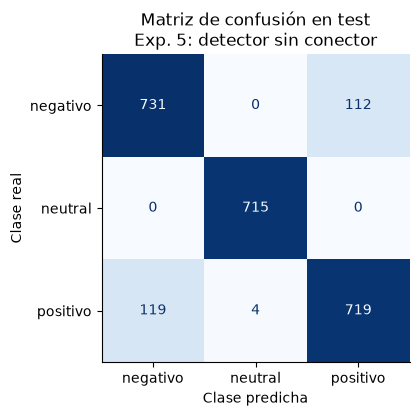

Negativo vs positivo en test: 0.861


In [13]:
metricas_e5 = evaluar_en_test(busqueda_e5.best_estimator_, "Exp. 5: detector sin conector")
np_test = (y_test != "neutral").to_numpy()
print(f"Negativo vs positivo en test: {(metricas_e5['pred'][np_test] == y_test.to_numpy()[np_test]).mean():.3f}")

### 2.8 Prueba de robustez en test

In [14]:
def desordenar_oraciones(textos, seed=SEED):
    rng = np.random.default_rng(seed)
    salida = []
    for texto in textos:
        oraciones = dividir_oraciones(texto)
        salida.append(" ".join(rng.permutation(oraciones)) if len(oraciones) > 1 else texto)
    return pd.Series(salida, index=textos.index)


def ultima_al_inicio(textos):
    def mover(texto):
        oraciones = dividir_oraciones(texto)
        return " ".join([oraciones[-1]] + oraciones[:-1])
    return textos.map(mover)


ESCENARIOS = {
    "Original": X_test,
    "Oraciones desordenadas": desordenar_oraciones(X_test),
    "Última oración al inicio": ultima_al_inicio(X_test),
}
filas = [{"modelo": "Exp. 5", "escenario": e, "accuracy": accuracy_score(y_test, busqueda_e5.best_estimator_.predict(X_e))}
         for e, X_e in ESCENARIOS.items()]
robustez = pd.concat([ROBUSTEZ_TEST_REF, pd.DataFrame(filas)], ignore_index=True)
robustez.pivot(index="escenario", columns="modelo", values="accuracy").reindex(list(ESCENARIOS)).round(4)

modelo,Exp. 2,Exp. 4,Exp. 5
escenario,,,
Original,0.8992,0.8975,0.9021
Oraciones desordenadas,0.6858,0.7358,0.7379
Última oración al inicio,0.5742,0.5946,0.5954


### 2.9 Registro y envío

In [15]:
registrar_resultado(
    experimento=5,
    descripcion="Como el exp. 4, con el detector de opinión aplicado a la oración sin su conector inicial",
    busqueda=busqueda_e5,
    metricas_test=metricas_e5,
    envio="submission_05.csv",
)

,experimento,descripcion,mejores_params,acc_train,acc_cv,std_cv,f1_cv,acc_test,f1_test,envio,kaggle_publico
0,1,"Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",{'clf__C': 10},0.9973,0.7364,0.0128,0.7478,0.7238,0.7366,submission_01.csv,NaN
1,2,"TF-IDF (1,2) de texto completo + última oración + tras el último conector + LR",{'clf__C': 10},0.9999,0.8865,0.0099,0.8908,0.8992,0.9031,submission_02.csv,0.88
2,3,"TF-IDF (1,2) de texto completo + oraciones con conector conclusivo + LR (sin posición)",{'clf__C': 10},0.9980,0.7978,0.0146,0.8064,0.7963,0.8054,submission_03.csv,NaN
3,4,"Texto completo + última oración con opinión (detector) + tras conector sin evasivas, LinearSVC","{'clf': 'LinearSVC', 'clf__C': 0.2}",0.9770,0.9009,0.0057,0.9055,0.8975,0.9021,submission_04.csv,NaN
4,5,"Como el exp. 4, con el detector de opinión aplicado a la oración sin su conector inicial","{'clf': LinearSVC(max_iter=5000, random_state=42), 'clf__C': 0.2}",0.9773,0.9022,0.0080,0.9068,0.9021,0.9068,submission_05.csv,NaN


In [16]:
envio_e5 = generar_envio(busqueda_e5, numero=5)

Envío guardado en envios/submission_05.csv y modelo en modelos/modelo_05.joblib
Distribución de predicciones en eval (%):
answer
negativo    35.6
neutral     27.7
positivo    36.8


### 2.10 Análisis del experimento 5

**Resultados:** accuracy de CV = **0,9022 ± 0,0080** (LinearSVC, `C = 0,2`, elegido entre regresión logística y
LinearSVC con sus propias grillas) y accuracy en test = **0,9021**.

| | Exp. 2 | Exp. 4 | Exp. 5 |
|---|---|---|---|
| Accuracy CV | 0,8865 | 0,9009 | **0,9022** |
| Accuracy test | 0,8992 | 0,8975 | **0,9021** |
| Test, oraciones desordenadas | 0,686 | 0,736 | 0,738 |
| Test, última oración al inicio | 0,574 | 0,595 | 0,595 |

1. **La mejora sobre el experimento 4 está dentro del ruido** (+0,13 puntos en CV, gana en 4 de 5 folds). En el test
   es la mejor cifra hasta ahora (0,9021), pero la diferencia (≈ 11 reseñas) también está dentro del error estándar
   (≈ 0,006). Según la regla del proyecto, la decisión se basa en la CV: el experimento 5 es, como mucho, un empate
   técnico con el 4.
2. **El detector ya está cerca de su máximo:** ninguna de las variantes probadas lo mejora de forma clara, y la
   interacción por tipo de conector empeora.
3. **El techo es ≈ 0,937:** el 12,6 % de las reseñas de train tiene una etiqueta prácticamente aleatoria (11,2 %
   termina en evasiva; 1,4 % tiene una última opinión con conector secundario que contradice a la anterior). **Fuera
   de esos grupos, el modelo ya acierta el 95,7 %.** El margen corregible que queda es de ≈ 3,5 puntos y corresponde
   sobre todo a errores al leer la polaridad de oraciones concretas (errores de tipeo, expresiones poco frecuentes).
4. **Sigue dependiendo de la posición** (robustez igual a la del experimento 4).

**Decisión:** el experimento 5 se envía como `submission_05.csv`. Su mejora es pequeña, pero es la mejor
configuración según la CV y completa los **5 envíos mínimos** exigidos para la participación. Más que mejorar el
score, su principal aporte es el **análisis del techo**: explica por qué los ajustes finos ya no mueven la accuracy y
por qué diferencias de ±0,01–0,02 en el leaderboard público son esperables.

**Próximo paso:** probar un modelo en dos niveles (experimento 6) que combine la polaridad estimada de cada oración
con su tipo de conector, para intentar recuperar parte de los ≈ 3,5 puntos corregibles.